In [98]:
using Pkg
Pkg.activate("TASEP")
#Pkg.instantiate()
include("./modules/transcription.jl")

  Activating project at `C:\Users\ChemeGrad2021\Documents\Braatz Group\MRNA Synthesis\TASEP\TASEP`


plotparametricellipse (generic function with 1 method)

In [71]:
#Basic parameters (from Stover et al, 2023)
k_on = 10^2.30 #P-DNA binding (hours^-1 nM^-1)
k_off = 10^3.74 #P-DNA binding (inverse hours)
k_i = 1500 #Initiation rate (inverse hours)
k_e = 10^5.5 #Elongation rate (inverse hours)

#Basic pausing parameters (Klumpp and Hwa, 2008)
τ = 1/3600 #Pausing time (hours)
f = 0.1*3600 #Pausing frequency (inverse hours)

#Basic T7 RNA polymerase size parameter (My best guess + Klumpp and Hwa, 2008)
L = 25

#Basic sequence parameter 
N_all = 2117;#Fluc sequence

##### Composite parameters (see overleaf derivation)
println("k_i = "*string(round(k_i; digits = 2))*" /hr")

α = 1+N_all*k_i/k_e     #Dimless
println("α = "*string(round(α; digits = 2)))

K = (k_off+k_i)/k_on     #nM
println("K = "*string(round(K; digits = 2))*" nM")

β = L*k_i^2/(k_e*k_on)   #Dimless
println("β = "*string(round(β; digits = 2)))

θ = k_off/k_on;          #nM
println("θ = "*string(round(θ; digits = 2))*" nM")

γ = k_i*f*τ^2/(1+f*τ)    #Dimless
println("γ = "*string(round(γ; digits = 2)))

p_initlimited = ComponentVector((k_i = k_i, K = K))
p_initelongation = ComponentVector((k_i = k_i, K = K, α = α))
p_basicTASEP = ComponentVector((k_i = k_i, K = K, α = α, β = β))
p_longTASEP = ComponentVector((k_i = k_i, K = K, α = α, β = β, γ = γ, θ = θ))

initiationlimited = InitiationLimitedModel()
initiationelongation = InitiationElongationModel()
basicTASEP = BasicTASEPModel()
longTASEP = LPTASEPModel()

p_base = ComponentVector((k_on = k_on, k_off = k_off, k_i = k_i, k_e = k_e, L = L, f = f, τ = τ, N_all = N_all))
p_composite = ComponentVector((k_i = k_i, α = α, K = K, γ = γ, β = β, θ = θ, N_all = N_all))

plott = 0.1
plotD = 10
plotP = 300;

k_i = 1500.0 /hr
α = 11.04
K = 35.06 nM
β = 0.89
θ = 27.54 nM
γ = 0.04


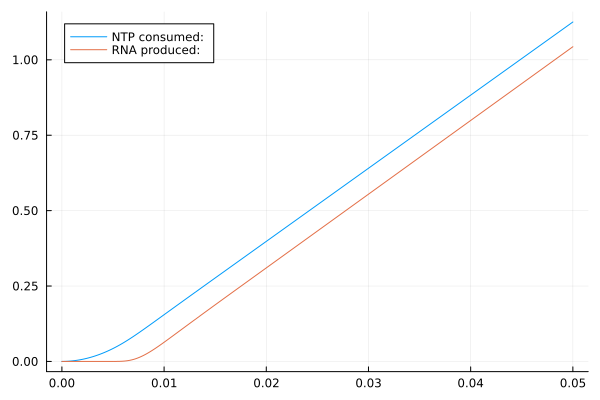

In [3]:
plt = plot()
plottemporaloutput!(plt, basicTASEP, p_base, plotD, plotP, 0.05)

[ Info: Saved animation to C:\Users\ChemeGrad2021\Documents\Braatz Group\MRNA Synthesis\TASEP\figures\propagate.gif


Plots.AnimatedGif("C:\\Users\\ChemeGrad2021\\Documents\\Braatz Group\\MRNA Synthesis\\TASEP\\figures\\propagate.gif")
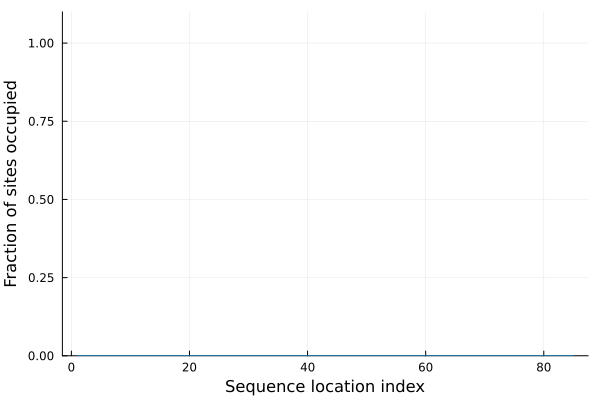

In [4]:
continuumanimation(longTASEP, p_base, plotD,300,plott)

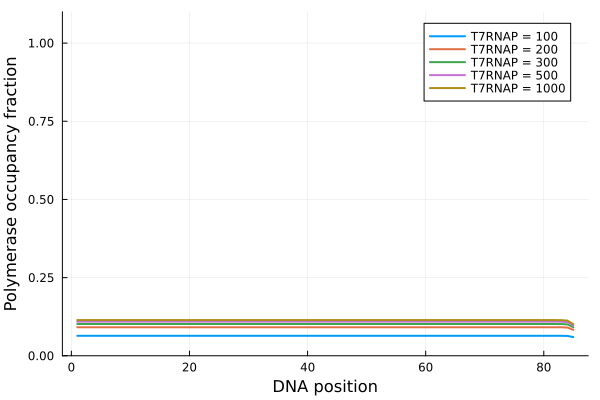

In [5]:
plt = densitydistributionfinal(basicTASEP, p_base, 10,100, plotlabel = "T7RNAP = 100")
densitydistributionfinal!(plt,basicTASEP, p_base, 10,200, plotlabel = "T7RNAP = 200")
densitydistributionfinal!(plt,basicTASEP, p_base, 10,300, plotlabel = "T7RNAP = 300")
densitydistributionfinal!(plt,basicTASEP, p_base, 10,500, plotlabel = "T7RNAP = 500")
densitydistributionfinal!(plt,basicTASEP, p_base, 10,1000, plotlabel = "T7RNAP = 1000")
savefig(plt,"./figures/finalhist.png")
plt

<h1>Showing that Analytic Approximations are Legitimate in Studied Range<h1>

In [ ]:
Pmax = 100
Pmin = 1
transcriptionmodel = basicTASEP
npoints = 100
cov = 0
QSkwargs = (showuncertainty = false, thinparameters = false, npoints = npoints, color = :black)
dynamickwargs = (showuncertainty = false, thinparameters = false, npoints = npoints, color = :red, analytic=false)

plt = plotQSrate_constantD(transcriptionmodel, p_composite, cov, p_base, 1, (Pmin,Pmax); modellabel = "1 nM DNA, Analytic", QSkwargs...)
plotQSrate_constantD!(plt, transcriptionmodel, p_composite, cov, p_base, 5, (Pmin,Pmax); modellabel = "5 nM DNA, Analytic", QSkwargs...)
plotQSrate_constantD!(plt, transcriptionmodel, p_composite, cov, p_base, 10, (Pmin,Pmax); modellabel = "10 nM DNA, Analytic", QSkwargs...)
plotQSrate_constantD!(plt, transcriptionmodel, p_composite, cov, p_base, 50, (Pmin,Pmax); modellabel = "50 nM DNA, Analytic", QSkwargs...)
plotQSrate_constantD!(plt, transcriptionmodel, p_composite, cov, p_base, 100, (Pmin,Pmax); modellabel = "100 nM DNA, Analytic", QSkwargs...)

plotQSrate_constantD!(plt, transcriptionmodel, p_base, cov, p_base, 1, (Pmin,Pmax); modellabel = "1 nM DNA, Direct", dynamickwargs...)
plotQSrate_constantD!(plt, transcriptionmodel, p_base, cov, p_base, 5, (Pmin,Pmax); modellabel = "5 nM DNA, Direct", dynamickwargs...)
plotQSrate_constantD!(plt, transcriptionmodel, p_base, cov, p_base, 10, (Pmin,Pmax); modellabel = "10 nM DNA, Direct", dynamickwargs...)
plotQSrate_constantD!(plt, transcriptionmodel, p_base, cov, p_base, 50, (Pmin,Pmax); modellabel = "50 nM DNA, Direct", dynamickwargs...)
plotQSrate_constantD!(plt, transcriptionmodel, p_base, cov, p_base, 100, (Pmin,Pmax); modellabel = "100 nM DNA, Direct", dynamickwargs...)
savefig(plt,"./figures/comparingapproxbasicTASEP.png")
plt

In [ ]:
Pmax = 100
Pmin = 1
transcriptionmodel = longTASEP
npoints = 100
cov = 0
QSkwargs = (showuncertainty = false, thinparameters = false, npoints = npoints, color = :black)
dynamickwargs = (showuncertainty = false, thinparameters = false, npoints = npoints, color = :red, analytic=false)

plt = plotQSrate_constantD(transcriptionmodel, p_composite, cov, p_base, 1, (Pmin,Pmax); modellabel = "1 nM DNA, Analytic", QSkwargs...)
plotQSrate_constantD!(plt, transcriptionmodel, p_composite, cov, p_base, 5, (Pmin,Pmax); modellabel = "5 nM DNA, Analytic", QSkwargs...)
plotQSrate_constantD!(plt, transcriptionmodel, p_composite, cov, p_base, 10, (Pmin,Pmax); modellabel = "10 nM DNA, Analytic", QSkwargs...)
plotQSrate_constantD!(plt, transcriptionmodel, p_composite, cov, p_base, 50, (Pmin,Pmax); modellabel = "50 nM DNA, Analytic", QSkwargs...)
plotQSrate_constantD!(plt, transcriptionmodel, p_composite, cov, p_base, 100, (Pmin,Pmax); modellabel = "100 nM DNA, Analytic", QSkwargs...)

plotQSrate_constantD!(plt, transcriptionmodel, p_base, cov, p_base, 1, (Pmin,Pmax); modellabel = "1 nM DNA, Direct", dynamickwargs...)
plotQSrate_constantD!(plt, transcriptionmodel, p_base, cov, p_base, 5, (Pmin,Pmax); modellabel = "5 nM DNA, Direct", dynamickwargs...)
plotQSrate_constantD!(plt, transcriptionmodel, p_base, cov, p_base, 10, (Pmin,Pmax); modellabel = "10 nM DNA, Direct", dynamickwargs...)
plotQSrate_constantD!(plt, transcriptionmodel, p_base, cov, p_base, 50, (Pmin,Pmax); modellabel = "50 nM DNA, Direct", dynamickwargs...)
plotQSrate_constantD!(plt, transcriptionmodel, p_base, cov, p_base, 100, (Pmin,Pmax); modellabel = "100 nM DNA, Direct", dynamickwargs...)
savefig(plt,"./figures/comparingapproxlongTASEP.png")
plt

<h1>Comparing Heirachies of Model Complexity<h1>

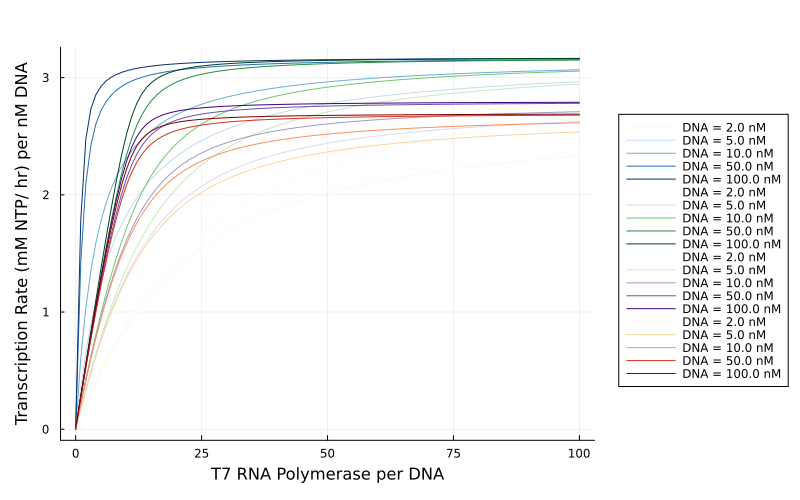

In [6]:
# transcriptionmodel = initiationlimited
# npoints = 100
# normalizexaxis = true
# normalizeyaxis = true

DNApoints = [2,5,5,10,50,100]
Ppoints = [200]
DPinputs = generategridinputs(DNApoints,Ppoints)
heirarchykwargs = (normalizexaxis = true, normalizeyaxis = true, showuncertainty = false, thinparameters = false)
modellist = [initiationlimited,initiationelongation,basicTASEP,longTASEP]
modelnamelist = ["Initiation limited","Initiation-elongation","Basic TASEP","Long Pause TASEP"]
modelcolorlist = [:Blues,:Greens,:Purples,:OrRd];

plt = plot(xlabel = "T7 RNA Polymerase per DNA", ylabel = "Transcription Rate per (mM NTP/ hr) per nM DNA")

for (jind,model) in enumerate(modellist)
    plotmodelprediction!(plt,model,p_composite,0,p_base,DPinputs;color =modelcolorlist[jind], modelname= modelnamelist[jind], heirarchykwargs...)
end
plot!(legend = :outerright, size = (800,500),leftmargin = 5mm, bottommargin = 5mm, topmargin = 10mm)
savefig(plt,"./figures/comparingallmodels_normalized.png")
plt

<h1>Practical Identifiability of TASEP Models<h1>

In [103]:
function evaluatemodelfitting(truemodelindex,testmodelindex,noiseval;plotresults = true,uncertaintyparams = true)
    DNApoints = [10,20,50,100]
    Ppoints = [100,200,300,500,800]
    extraDNA = []
    npoints = 1000#Number of multistart points used
    meanK = 50
    stdK = 25
    priorfunc = x->((x[end]-meanK)/stdK)^2
    priormat = [0 0 0 0 0;0 1/stdK^2 0 0 0;0 0 0 0 0;0 0 0 0 0;0 0 0 0 0]
    priormatlist = [priormat[1:2,1:2],priormat[1:3,1:3],priormat[1:4,1:4],priormat]
    ###########You don't have to change anything below this line################
    truemodel = modellist[truemodelindex]
    truemodelname = modelnamelist[truemodelindex]
    testmodel = modellist[testmodelindex]
    testmodelname = modelnamelist[testmodelindex]

    DPinputs = generategridinputs(DNApoints,Ppoints)
    experimentalnoise = noiseval*ones(size(DPinputs)[1])
    experimentaldata = generatesyntheticdata(truemodel,p_composite,DPinputs,experimentalnoise)

    normalizexaxis = false
    normalizeyaxis = false
    if plotresults
        plt = plot()
        plotexperimentaldata!(plt,DPinputs,experimentaldata,experimentalnoise,extraDNA = extraDNA)
        (p_null,p_thintrue,truecov) = multistartoptimizeparams(truemodel, experimentaldata, DPinputs, experimentalnoise, p_base, npoints = npoints, priorfunc = priorfunc, priormat = priormatlist[truemodelindex])
        (p_estimated,p_thintest,testcov) = multistartoptimizeparams(testmodel, experimentaldata, DPinputs, experimentalnoise, p_base, npoints = npoints, priorfunc = priorfunc, priormat = priormatlist[testmodelindex])
        plotmodelprediction!(plt,testmodel,p_thintest,testcov,p_base,DPinputs,normalizexaxis = normalizexaxis,normalizeyaxis =normalizeyaxis, modelname = testmodelname, maximumT7 = 800, color =  :Dark2_5, showuncertainty = false, extraDNA = extraDNA)
        plot!(legend = :outertop)
        display(plt)
        pltelps1 = plotparametricellipse(p_thintrue,truecov,title = truemodelname)
        display(pltelps1)
        pltelps2 = plotparametricellipse(p_thintest,testcov,title = testmodelname)
        display(pltelps2)
    end
    if uncertaintyparams
        println("Parameter Estimates (Ground Truth Model)")
        printuncertaintyestimates(p_thintrue,truecov,N_all)
        println("Parameter Estimates (Test Model)")
        printuncertaintyestimates(p_thintest,testcov,N_all)
    end
end

evaluatemodelfitting (generic function with 1 method)

In [ ]:
evaluatemodelfitting(3,2,8)

In [96]:
1-β/(K-θ)

0.8814145877436858

In [92]:
1284.5/1500.0

0.8563333333333333